In [2]:
import os
import json
from pathlib import Path

import torch
from transformers import (
    AutoModelForImageTextToText,
    AutoProcessor,
)
from transformers.image_utils import load_image

IMAGE_DIR = "./data"
OUTPUT_FILE = "dataset.jsonl"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(DEVICE)

processor = AutoProcessor.from_pretrained("HuggingFaceTB/SmolVLM-256M-Instruct")
model = AutoModelForImageTextToText.from_pretrained(
    "HuggingFaceTB/SmolVLM-256M-Instruct",
    dtype=torch.bfloat16,
    _attn_implementation="flash_attention_2" if DEVICE == "cuda" else "eager",
).to(DEVICE)

cpu


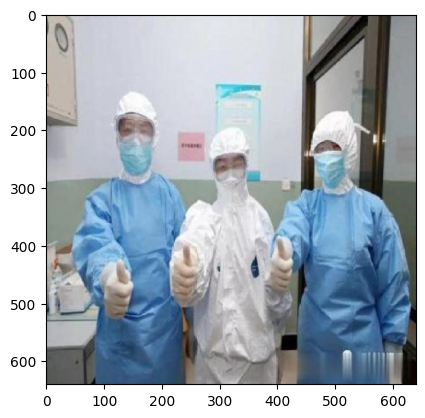

Промпт: How many people are at the picture? Describe them in detail
Ответ:  There are three people at the picture.


In [4]:
import matplotlib.pyplot as plt
import cv2

TEST_IMAGE = Path(IMAGE_DIR + "/0000000013_jpg.rf.a7b4df633397510725f11d8daa0592cb.jpg")

image = cv2.imread(TEST_IMAGE)[:,:,::-1]
plt.imshow(image)
plt.show()

TEST_PROMPT = "How many people are at the picture? Describe them in detail"

if not TEST_IMAGE.is_file():
    raise FileNotFoundError(f"Картинка не найдена: {TEST_IMAGE.resolve()}")

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": str(TEST_IMAGE)},
            {"type": "text", "text": TEST_PROMPT},
        ],
    }
]

text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
)

inputs = processor(
    text=[text],
    images=[load_image(str(TEST_IMAGE))],
    padding=True,
    return_tensors="pt",
)
inputs = inputs.to(DEVICE)

generated_ids = model.generate(
    **inputs,
    max_new_tokens=128,
    do_sample=False,
)

generated_ids_trimmed = [
    out_ids[len(in_ids):]
    for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
]

answer = processor.batch_decode(
    generated_ids_trimmed,
    skip_special_tokens=True,
    clean_up_tokenization_spaces=False,
)[0]

print("Промпт:", TEST_PROMPT)
print("Ответ:", answer)

In [5]:
PROMPT = """Describe the image briefly and informatively.
Include:
- main objects;
- actions;
- scene.
Answer in one sentence.
DESCRIBE AS DETAILED AS POSSIBLE, EVERY ELEMENT, EVERY ACTION!!!
"""

all_items = []

files = sorted(os.listdir(IMAGE_DIR))

for file_name in files:

    if not file_name.lower().endswith(
        (".jpg", ".jpeg", ".png", ".webp")
    ):
        continue

    image_path = os.path.join(IMAGE_DIR, file_name)

    print(f"Processing: {file_name}")

    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image_path
                },
                {
                    "type": "text",
                    "text": PROMPT
                }
            ]
        }
    ]

    text = processor.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = processor(
        text=[text],
        images=[load_image(image_path)],
        padding=True,
        return_tensors="pt"
    )

    inputs = inputs.to(DEVICE)

    generated_ids = model.generate(
        **inputs,
        max_new_tokens=512,
        do_sample=False
    )

    generated_ids_trimmed = [
        out_ids[len(in_ids):]
        for in_ids, out_ids in zip(
            inputs.input_ids,
            generated_ids
        )
    ]

    output_text = processor.batch_decode(
        generated_ids_trimmed,
        skip_special_tokens=True,
        clean_up_tokenization_spaces=False
    )[0]

    item = {
        "image": image_path,
        "text": output_text
    }

    all_items.append(item)

    print(output_text)

Processing: -01-16-2-3-2-5-15_jpg.rf.3a82c0e7cb6b006df4c9fc87d9b55368.jpg
 The room has a large room square with a table in the middle. On the table are brown boxes stacked on top of each other.
Processing: -01-16-2-3-2-5-15_jpg.rf.705a29a51fa44f15dbe29adcaf09d2e0.jpg
 The room has several boxes stacked on top of each other.
Processing: -01-16-2-3-2-5-20_jpg.rf.ff89baa4ddffc68390a744645a32236d.jpg
 The image depicts a classroom setting with several cardboard boxes prominently displayed. The boxes are positioned in a way that suggests they are intended for distribution or storage purposes. The cardboard appears to be a standard size, possibly a box for shipping or packaging.

In the foreground, there is a large, rectangular cardboard box that is open and has a label on it. The label is prominently displayed in white text, with the word "FLOWER" written in a stylized font. The text is in a bold, sans-serif font, making it stand out clearly. The box is open, revealing a glimpse of the int

KeyboardInterrupt: 

In [6]:
with open(OUTPUT_FILE, "w", encoding="utf-8") as f:
    for item in all_items:
        f.write(
            json.dumps(item, ensure_ascii=False) + "\n"
        )

print(f"Saved to {OUTPUT_FILE}")

Saved to dataset.jsonl
